In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [2]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [3]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index


In [4]:
X, var_index = gen_data(2, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=42)
print("Data shape:", X.shape)
print("Variable index:", var_index)

100%|██████████| 2/2 [00:02<00:00,  1.47s/it]

Data shape: (2, 1000, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


In [5]:
# --- Save data ---
# B_gen = 100
# dataX, var_index  = gen_data(B_gen, data_cols, currents='pulse', I_low=0.25, I_high=1.0)
# np.savez(f'data_PHNN/data_c_pulse_dt_{T}.npz', X=dataX, var_index=var_index)

In [6]:
# --- Load data ---
def load_data(path, var_index = var_index):
    with np.load(path) as d:
        X = d['X']  # replace 'X' with the actual key if different

    data = {var: X[:, :, idx] for var, idx in var_index.items()}
    return data

# path = f'data_PHNN/data_c_DC_dt_{T}.npz'
path = f'data_PHNN/data_c_pulse_dt_{T}.npz'
# path = f'data_PHNN/data_c_GRF_dt_{T}.npz'
D = load_data(path)
I = D['I']; V = D['V']; ocv = D['ocv']
B = I.shape[0]

D['valid'] = D['valid'].astype(bool)

In [7]:
# --- Normalization ---
stats = {}
def compute_stats(D=D,data_cols=data_cols):
    for name in data_cols:
        stats[name] = (float(D[name].ravel()[D['valid'].ravel()].mean()), float(max(D[name].ravel()[D['valid'].ravel()].std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize

I_n = transform(I, 'I')
V_n = transform(V, 'V')
ocv_n = transform(ocv, 'ocv')

In [8]:
# --- Split data ---
x = torch.tensor(np.stack([I_n], axis=-1), dtype=torch.float32) # (B, T, 4)
print(x.shape)
y = torch.tensor(np.stack([V_n, ocv_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(D['valid'], dtype=torch.float32)

split = int(0.8 * B)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)

# Flatten time dimension for training and split
x_train, x_test = _split_flat(x)        
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

# # Unflattened
x_train_batch, x_test_batch = _split(x) # (B, T, 4)
y_train_batch, y_test_batch = _split(y)
mask_train_batch, mask_test_batch = _split(mask)

# Un-normalized for plotting
I_train,      I_test      = _split(I)
V_train,      V_test      = _split(V)
ocv_train,    ocv_test    = _split(ocv)
mask_train_plot, mask_test_plot = _split(D['valid'])

batch_size_small = int(B/4)
# batch_size_large = int(B*T/4)
train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
# train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

torch.Size([100, 1000, 1])


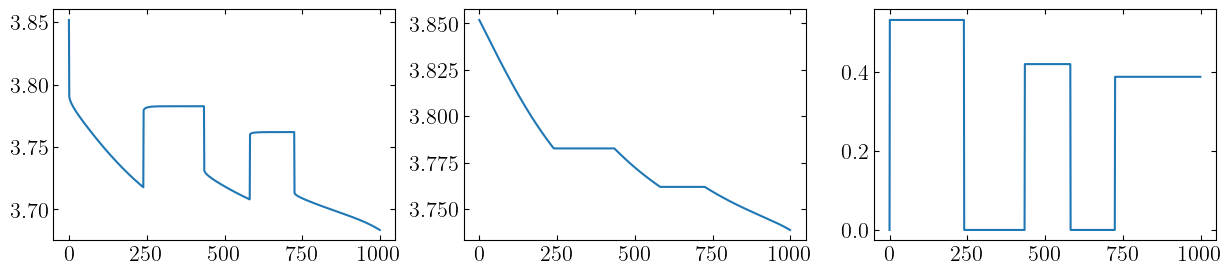

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(V_test[0, :], label='cn')
axes[1].plot(ocv_test[0, :], label='valid')
axes[2].plot(I_test[0, :], label='dI')


In [16]:
# Parameter identification via gradient descent
class BatteryPHNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),   # Q, q
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    #     self.r0_raw = nn.Parameter(torch.tensor(0.1))
    #     self.r1_raw = nn.Parameter(torch.tensor(0.1))
    #     self.c1_raw = nn.Parameter(torch.tensor(100.0))

    # @property
    # def R0(self): return nn.functional.softplus(self.r0_raw)
    # @property
    # def R1(self): return nn.functional.softplus(self.r1_raw)
    # @property
    # def C1(self): return nn.functional.softplus(self.c1_raw)
        self.R1 = nn.Parameter(torch.tensor(0.1)) 
        self.R0 = nn.Parameter(torch.tensor(0.01)) 
        self.C1 = nn.Parameter(torch.tensor(100.0))

    def forward(self, x):
        return nn.functional.softplus(self.net(x))   # (B, 1)

model = BatteryPHNN()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [19]:
def dH_dx(pred, x):
    H = pred  # (B, 1)
    dH_dx = torch.autograd.grad(H, x, grad_outputs=torch.ones_like(H), create_graph=True)[0]
    dH_dx[:, 1] = torch.sqrt(2 * H / model.C1).squeeze(1)  # From C1 = 2H / (dH_dq)^2
    return dH_dx

def dynamics(pred, x, I_t):
    dH_dq = dH_dx(pred, x)[:, 1]

    dQ  = - I_t
    dq1 = I_t - dH_dq/ (model.R1)
    return torch.stack([dQ, dq1], dim=1)

def euler_step(pred, x, I_t, dt):
    dx = dynamics(pred, x, I_t)   # (B, 2)
    return x + dx * dt            # (B, 2)




# Rollout for different dt
def rollout(model, x, I_phys, ocv_phys, dt, evalu=False):
    '''
    x        : (B, 2)  initial states [Q0, q1_0], requires_grad=True
    I_phys   : (B, T)  physical current   (tensor or numpy)
    ocv_phys : (B, T)  physical OCV       (tensor or numpy)
    dt       : rollout step size (can differ from DT)
    '''
    B_b = x.shape[0]
    max_steps = int(T_HORIZON / dt)
    t_data = np.arange(T) * DT   # Original time points of the data (1000,)

    # Numpy arrays for interpolation
    I_np   = I_phys.detach().cpu().numpy()   if isinstance(I_phys, torch.Tensor) else I_phys
    ocv_np = ocv_phys.detach().cpu().numpy() if isinstance(ocv_phys, torch.Tensor) else ocv_phys

    V_pred_list = []
    C1 = []

    for step in range(max_steps):
        t = step * dt

        H_pred = model(x)  # (B, 1)
        dH_dq = dH_dx(H_pred, x)[:, 1]

        # Value at time t by interpolation
        I_t_np   = [float(np.interp(t, t_data, I_np[b])) for b in range(B_b)]
        ocv_t_np = [float(np.interp(t, t_data, ocv_np[b])) for b in range(B_b)]

        I_t   = torch.tensor(I_t_np,   dtype=torch.float32)   # (B,)
        ocv_t = torch.tensor(ocv_t_np, dtype=torch.float32)   # (B,)

        V_t_pred = ocv_t - model.R0 * I_t - dH_dq
        V_pred_list.append(V_t_pred)

        C1.append(2 * H_pred / dH_dq**2)

        x = euler_step(H_pred, x, I_t, dt)

    V_pred = torch.stack(V_pred_list, dim=1)   # (B, max_steps)

    if evalu:
        return V_pred, torch.stack(C1, dim=1), step   # (1, T), (1, T) Batches will be indexed away in eval
    return V_pred   # (B, T)


def masked_mse(pred, target, mask):
    err = (pred - target) ** 2    # (B, T)
    return (err * mask).sum() / (mask.sum() * 2)

def training(epochs=10, dt=DT):
    history = {"loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_batch:
            B_b = x_b.shape[0]
            x0 = torch.zeros(B_b, 2).requires_grad_(True)  # Initial states

            I_phys   = x_b[:, :, 0] * stats['I'][1] + stats['I'][0]         # Denormalize current (B, T)
            ocv_phys = y_b[:, :, 1] * stats['ocv'][1] + stats['ocv'][0]     # Denormalize OCV
            V_true_n = y_b[:, :, 0]                                         # Normalized voltage

            V_pred = rollout(model, x0, I_phys, ocv_phys, dt)     # (B, T)
            V_pred_n = (V_pred - stats['V'][0]) / stats['V'][1]         # Normalize predicted voltage

            loss = masked_mse(V_pred_n, V_true_n, mask_b)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tot_ep_loss += loss.item()

        avg_loss = tot_ep_loss / len(train_loader_batch)  # Average loss per batch
        end_t = time.perf_counter()

        history["loss"].append(avg_loss)
        #history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        print(f"Epoch {ep+1} | loss {avg_loss:.3e} | time {end_t - start_t:.2f}s")

    return history
    

In [20]:
history = training(epochs=10, dt=DT)

Epoch 1 | loss 7.315e-01 | time 2.95s
Epoch 2 | loss 3.060e-01 | time 2.49s
Epoch 3 | loss 1.725e-01 | time 2.75s
Epoch 4 | loss 1.143e-01 | time 2.69s
Epoch 5 | loss 6.829e-02 | time 2.79s
Epoch 6 | loss 4.399e-02 | time 2.64s
Epoch 7 | loss 3.227e-02 | time 2.62s
Epoch 8 | loss 1.721e-02 | time 2.83s
Epoch 9 | loss 1.421e-02 | time 2.59s
Epoch 10 | loss 1.238e-02 | time 2.78s


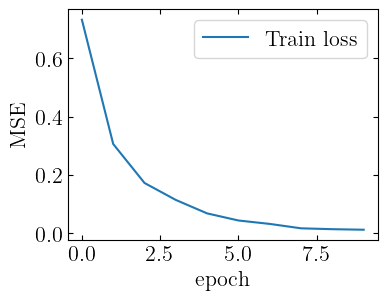

In [21]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend();

In [22]:
def eval_rollout_phnn(idx=0, dt=DT):
    model.eval()
    x_seq = x_test_batch
    y_seq = y_test_batch
    m_seq = mask_test_batch
    V_seq = V_test

    x_b = x_seq[idx:idx+1]            # (1, T, 1)
    y_b = y_seq[idx:idx+1]            # (1, T, 2)

    I_phys   = x_b[:, :, 0] * stats['I'][1] + stats['I'][0]         # Denormalize current (1, T)
    ocv_phys = y_b[:, :, 1] * stats['ocv'][1] + stats['ocv'][0]     # Denormalize OCV

    print('I',I_phys.shape)
    x0 = torch.zeros(1, 2).requires_grad_(True)  # Initial states
    V_pred_phys, C1, step = rollout(model, x0, I_phys, ocv_phys, dt, evalu=True)

    V_pred = V_pred_phys.squeeze(0).detach().numpy()     # (T,)
    V_true = V_seq[idx]                         # (T,)
    valid  = m_seq[idx].numpy().astype(bool)    # (T,)

    t_true = np.arange(m_seq.shape[1]) * DT
    t      = np.arange(step+1) * dt

    return V_pred, V_true, I_phys, t, t_true, valid, C1

I torch.Size([1, 1000])
R0: 0.109, R1: 0.005, C1 (final): 100.098, C1 (model): 100.098


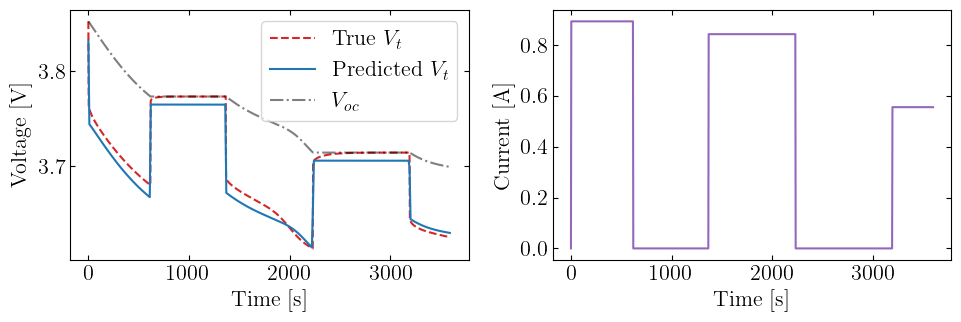

In [29]:
idx = 1
dt = 10
V_pred, V_true, I_phys, t_eval, t_true, valid, C1 = eval_rollout_phnn(idx, dt)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t_true[valid], V_true[valid], '--', color='tab:red', label=r'True $V_t$')
axes[0].plot(t_eval, V_pred, color='tab:blue',  label=r'Predicted $V_t$')            # TODO: Valid does not work for t_eval
axes[0].plot(t_true[valid], ocv_test[idx][valid], '-.', color='black', alpha=0.5, label=r'$V_{oc}$')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].legend()

print(f'R0: {model.R0.item():.3f}, R1: {model.R1.item():.3f}, C1 (final): {C1[0, -1].item():.3f}, C1 (model): {model.C1.item():.3f}')

axes[1].plot(t_true, I_phys[0, :], color='tab:purple', label=r'RC time constant $\tau$ [s]')
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Current [A]")

fig.tight_layout()
# fig.savefig('figs/PHNN_pred_pulse_train_GRF.pdf')